In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загружаем тренировочный датасет
train_df = pd.read_csv('data/train.csv')

In [3]:
#Смотрим первые 5 строчек датасета, чтобы увидеть, какие данные и признаки есть
train_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
#Получаем общую информацию по датасету, также смотрим какое количество значений в каждом признаке является "non-null"
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
#Смотрим распределение данных в каждом признаке
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:

#Получаем процентное соотношение пропущенных значений в каждом признаке
train_null = train_df.isnull().sum()[train_df.isnull().sum() > 0]
percent_null = round(train_df.isnull().sum()[train_df.isnull().sum() > 0] / 1460 * 100, 2)
train_null
percent_null.sort_values()

Electrical       0.07
MasVnrArea       0.55
BsmtCond         2.53
BsmtFinType1     2.53
BsmtQual         2.53
BsmtExposure     2.60
BsmtFinType2     2.60
GarageType       5.55
GarageQual       5.55
GarageFinish     5.55
GarageCond       5.55
GarageYrBlt      5.55
LotFrontage     17.74
FireplaceQu     47.26
MasVnrType      59.73
Fence           80.75
Alley           93.77
MiscFeature     96.30
PoolQC          99.52
dtype: float64

Text(0, 0.5, 'Percent missing')

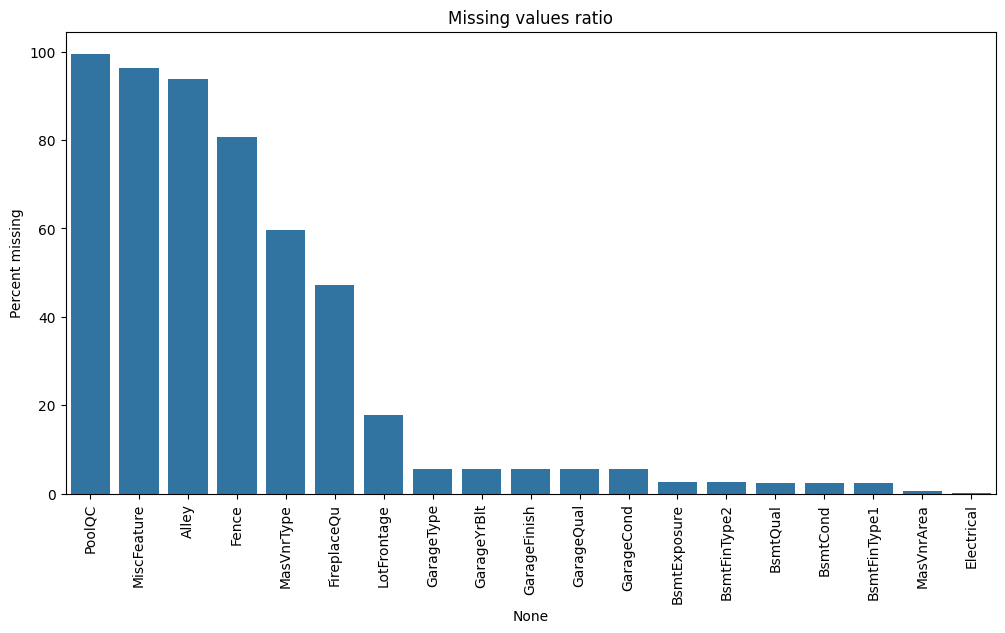

In [ ]:
#Выведем в порядке убывания признаки, у которых есть пропущенные значения
missing = percent_null.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing.index, y=missing.values)

plt.xticks(rotation=90)

plt.title("Missing values ratio")
plt.ylabel("Percent missing")
#Вывод: сразу видно, что у нескольких признаков есть огромное количество пропущенных значений: PoolQC, MiscFeaturem, Alley, Fence, MasVnrType

In [8]:
#Удаляем признаки, которые имеют максимальное процентное количество пропущенных значений
train_df = train_df.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], axis=1)

<Axes: xlabel='MasVnrType', ylabel='SalePrice'>

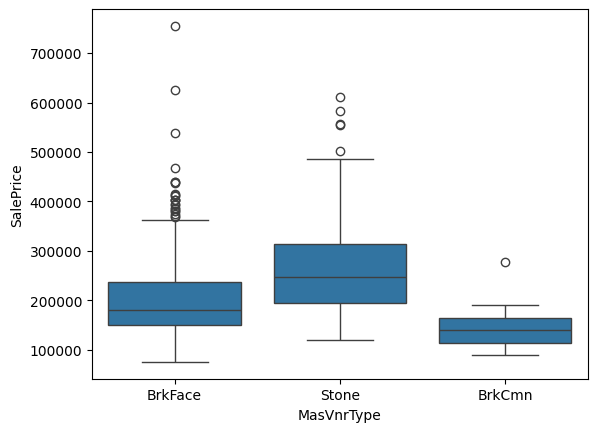

In [ ]:
#Смотрим распределение цены дома в зависимости от MasVnrType. Видно линейную зависимость цены дома от признака MasVnrType, что указывает на то, что данный признак будет полезен.
sns.boxplot(data=train_df, x=train_df["MasVnrType"], y=train_df["SalePrice"])
#Вывод: Видно, что стоимость дома зависит от того, из какой материала он построен

<Axes: xlabel='FireplaceQu', ylabel='SalePrice'>

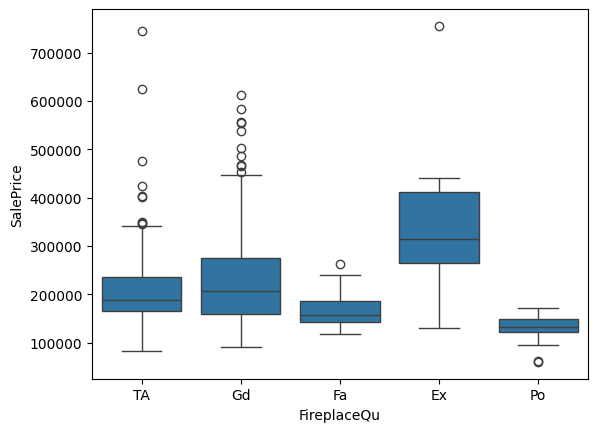

In [ ]:
#Смотрим распределение цены дома в зависимости от FireplaceQu. Видно линейную зависимость цены дома от признака FireplaceQU, что указывает на то, что данный признак будет полезен.
sns.boxplot(data=train_df, x=train_df["FireplaceQu"], y=train_df["SalePrice"])
#Вывод: Качество камина влияет на стоимость дома

<Axes: >

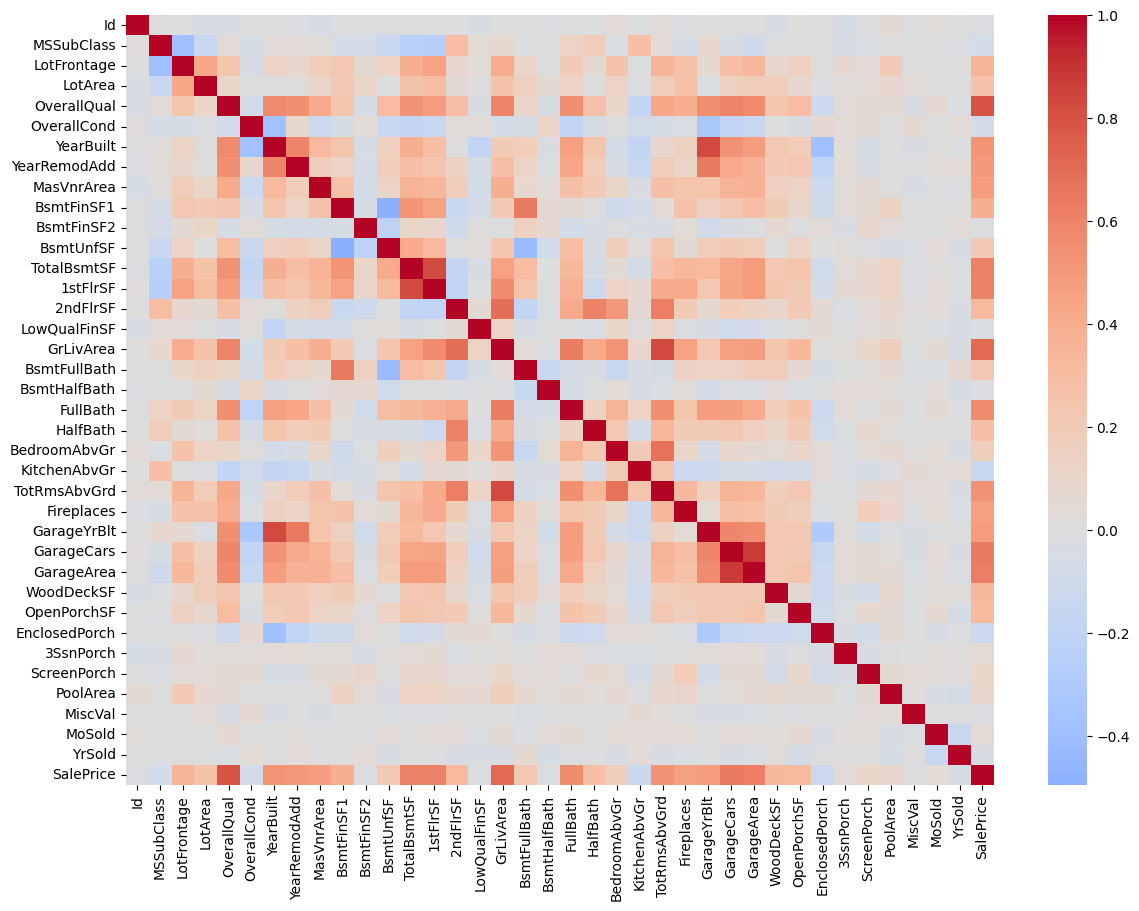

In [12]:
#Смотрим корреляцию числовых фичей, это поможет определить список фичей с самой высокой корреляции относительно Target
corr = train_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)

In [ ]:
#Чтобы явно увидеть в числах корреляцию, выведем в порядке убывания значения корреляции
top_corr = corr["SalePrice"].sort_values(ascending=False)
top_corr
#Вывод: сразу видно несколько интересных признаков, которые имеют высокое влияние на стоимость дома (OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

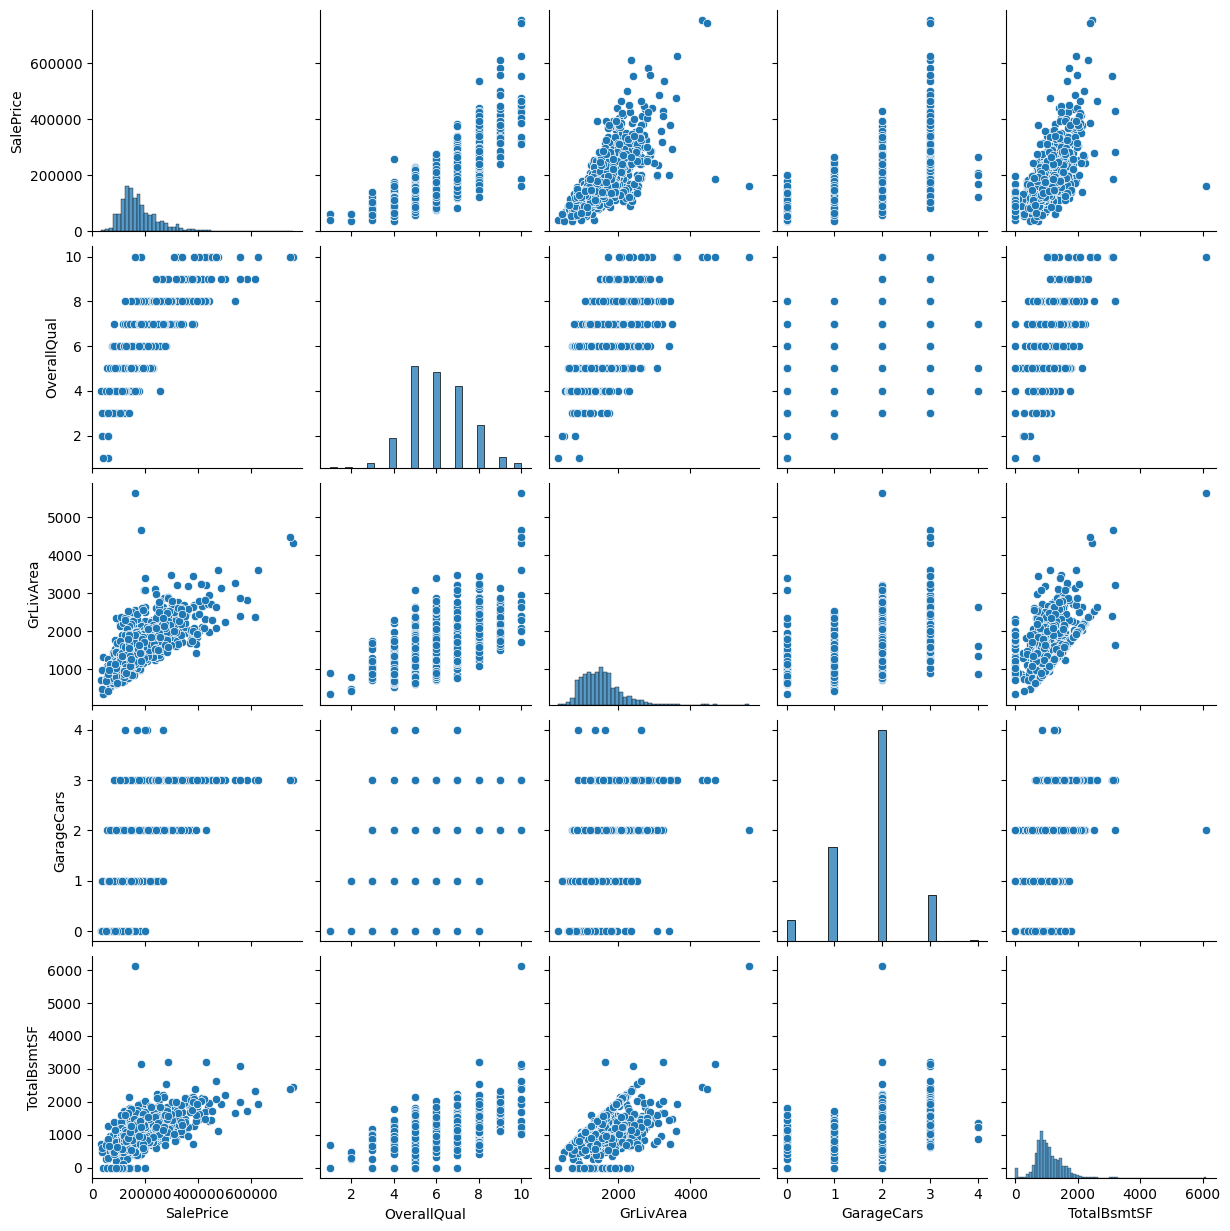

In [ ]:
#Теперь посмотрим зависимость между данным признаками, чтобы понять,  как они вляют друг на друга, есть ли выбросы.
sns.pairplot(train_df[["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF"]])

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

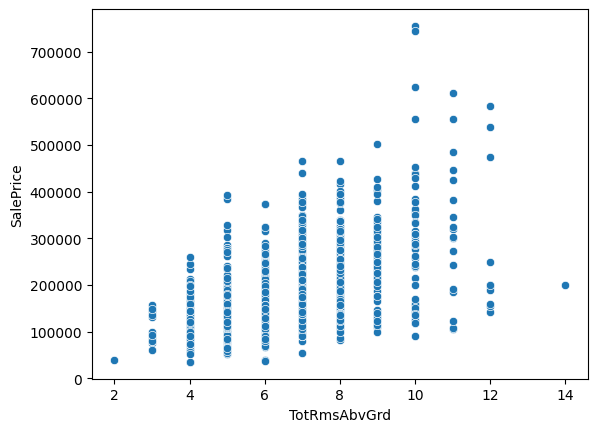

In [15]:
#Теперь смотрим линейную зависимость числовых фичей 
x = train_df["TotRmsAbvGrd"]
y = train_df["SalePrice"]
sns.scatterplot(data=train_df, x=x, y=y)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

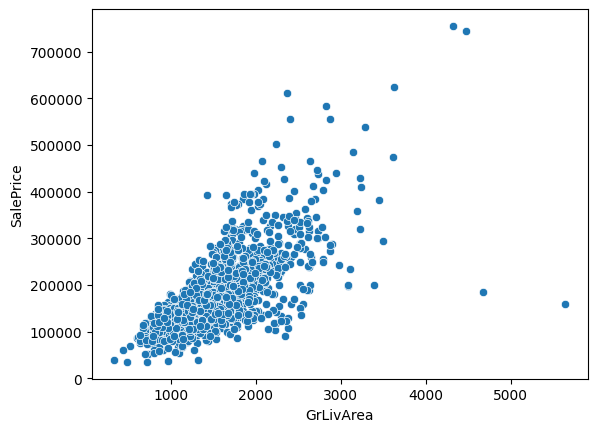

In [ ]:
#Здесь видно, что зависимость линейная, но есть два выброса с площадью больше 4000
x = train_df["GrLivArea"]
y = train_df["SalePrice"]
sns.scatterplot(data=train_df, x=x, y=y)

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

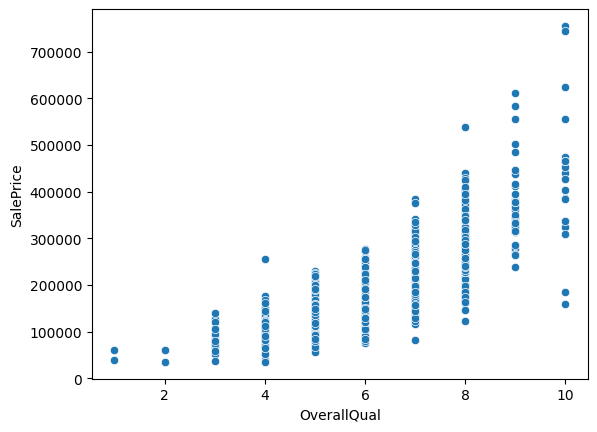

In [ ]:
#Видно линейную зависимость между качеством отделки и ценой дома.
x = train_df["OverallQual"]
y = train_df["SalePrice"]
sns.scatterplot(data=train_df, x=x, y=y)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

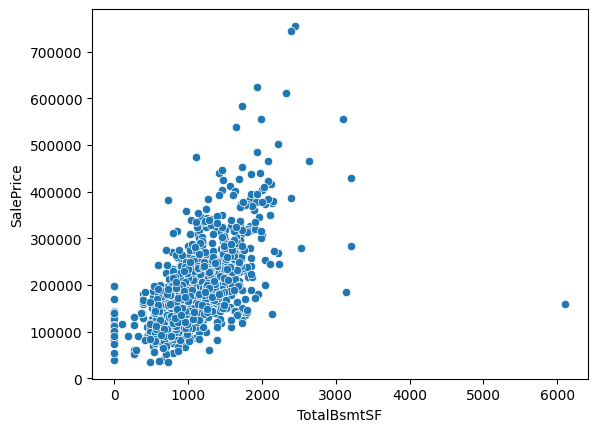

In [ ]:
#Площадь подвального помещения также линейно влияет на стоимость дома, в данном случае есть только один выброс, где площадь подвала больше 6000
x = train_df["TotalBsmtSF"]
y = train_df["SalePrice"]
sns.scatterplot(data=train_df, x=x, y=y)

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

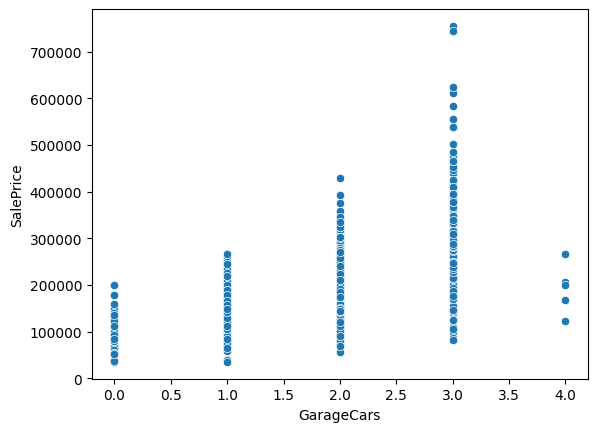

In [ ]:
#У нас было два признака, связанных с гаражом, посмотрим на один из них, как он влиет на цену дома, видно что зависимость линейная, есть также значение 4.0, которые выбивается из общей картины, но так как домов, где в гараж помещается от 4 машин не так много, поэтому данная ситуация не критична
x = train_df["GarageCars"]
y = train_df["SalePrice"]
sns.scatterplot(data=train_df, x=x, y=y)

In [20]:
#Смотрим распределение по таргету, чтобы понять, в какую сторону сдвиг у переменной (в данном случае вправо)
print(train_df["SalePrice"].skew())

1.8828757597682129


<Axes: xlabel='SalePrice', ylabel='Count'>

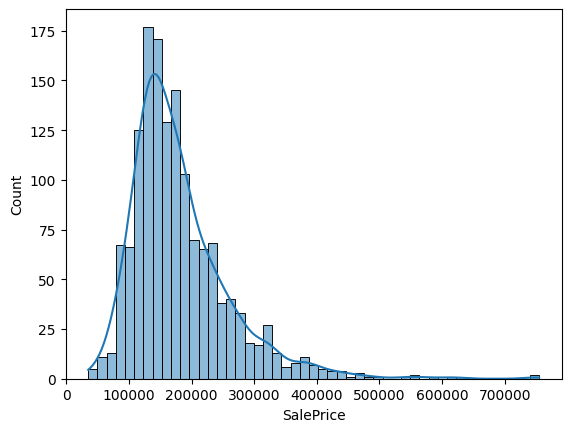

In [ ]:
#График показывает ценовое распределение, видно справа хвост, который говорит о том, что не так много домов с высокой стоимостью.
sns.histplot(train_df["SalePrice"], kde=True)

In [22]:
#Нужно привести таргет к нормальному распределению, поэтому воспользуемся логарифмированием, это позволит моделям лучше обучаться и делать предсказания
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])
print(train_df["SalePrice"].skew())

0.12134661989685333


<Axes: xlabel='SalePrice', ylabel='Count'>

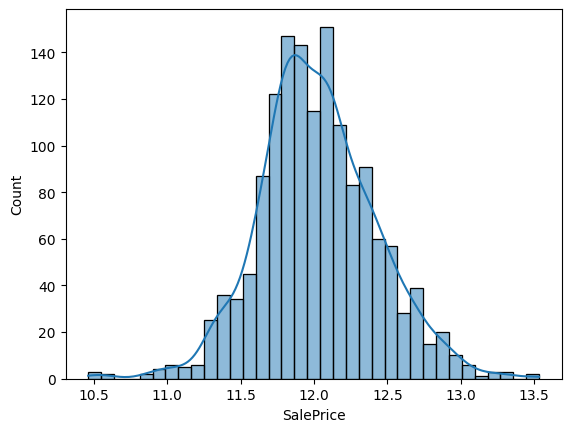

In [23]:
#На гистограмме смотрим теперь, как распределились значения таргета
sns.histplot(train_df["SalePrice"], kde=True)

In [24]:
#Посмотрим информацию по распределению остальных цифровых признаков
numeric_features = train_df.select_dtypes(include=np.number)
numeric_features.skew()

Id                0.000000
MSSubClass        1.407657
LotFrontage       2.163569
LotArea          12.207688
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        2.669084
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
BsmtFullBath      0.596067
BsmtHalfBath      4.103403
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      4.488397
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.649415
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
MoSold            0.212053
YrSold            0.096269
S

In [ ]:
#Выведем все категорильаные признаки, чтобы отобрать из них самые полезные
categorical_features = train_df.select_dtypes(include="object").columns
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
#Выведем влияние каждого категориального признака на таргет, это поможет нам получить полезные признаки, так как мы видим среднее значение по каждой группе и количество, можно сразу увидеть, есть ли выбросы, какое значение преобладает.
train_df.groupby('Neighborhood')["SalePrice"].agg(['mean', 'count'])
#Вывод: в данном примере видно, как влияет район на стоимость дома, какие районы реже встречаются, какие чаще

,mean,count
Neighborhood,,
Blmngtn,12.169421,17
Blueste,11.826543,2
BrDale,11.547874,16
BrkSide,11.679736,58
ClearCr,12.239905,28
CollgCr,12.163647,150
Crawfor,12.206664,51
Edwards,11.712321,100
Gilbert,12.155809,79


In [ ]:
#Создаем новый признак, который даст нам значения влияния качества и прощади на стоимость дома
train_df["QualityArea"] = (train_df["OverallQual"] * train_df["GrLivArea"])

<Axes: xlabel='QualityArea', ylabel='SalePrice'>

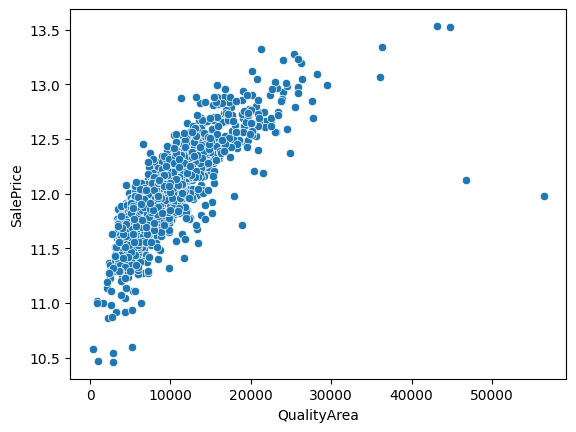

In [ ]:
sns.scatterplot(x='QualityArea', y='SalePrice', data=train_df)


In [ ]:
#Создаем признак, связанный с общей площадью, которая включает в себя дом и подвал
train_df["TotalArea"] = (train_df["GrLivArea"] + train_df["TotalBsmtSF"])


<Axes: xlabel='TotalArea', ylabel='SalePrice'>

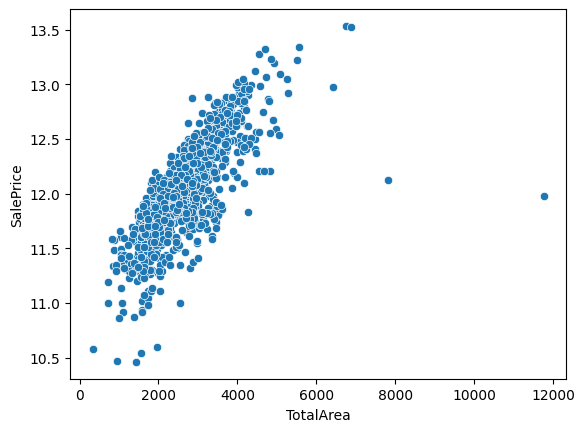

In [36]:
sns.scatterplot(x='TotalArea', y='SalePrice', data=train_df)

In [ ]:
#Данный признак позволит оценить, как качество отделки и вместимость гаража влияет на стоимость дома
train_df["QualityGarage"] = (train_df["OverallQual"] * train_df["GarageCars"])


<Axes: xlabel='TotalArea', ylabel='SalePrice'>

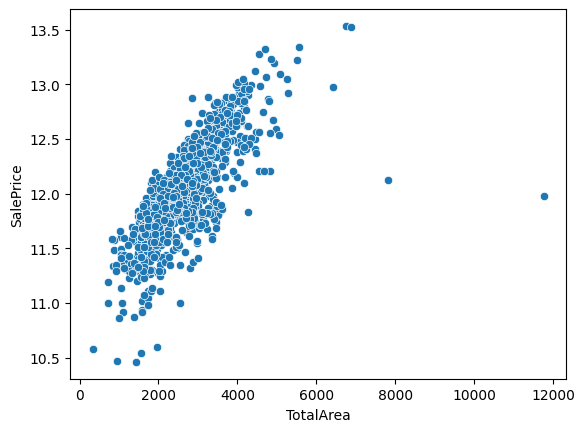

In [37]:
sns.scatterplot(x='TotalArea', y='SalePrice', data=train_df)